# 📊 Minh Họa Tập Dữ Liệu RDD - Image Segmentation & Feature Extraction

Hướng dẫn chi tiết về:
1. **Visualize Dataset** - Hiển thị tập dữ liệu
2. **Image Segmentation** - Phân vùng hình ảnh
3. **Feature Extraction** - Trích xuất đặc trưng

---

## Part 1: Setup & Data Loading

In [2]:
# Import libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Setup
DATA_DIR = "Road_Patches_Cracks_Segmentation_Datasets"
CLASS_NAMES = ["Crack", "Pothole"]
CLASS_COLORS = {"Crack": (255, 165, 0), "Pothole": (0, 0, 255)}  # BGR format

# Plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [3]:
def load_image_with_labels(img_dir, label_dir, img_filename):
    """
    Load image and its segmentation labels (YOLO format)
    
    YOLO format: class_id normalized_x1 normalized_y1 normalized_x2 normalized_y2 ...
    """
    img_path = os.path.join(img_dir, img_filename)
    label_path = os.path.join(label_dir, img_filename.rsplit('.', 1)[0] + '.txt')
    
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        return None, None, None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width = img.shape[:2]
    
    # Load annotations
    annotations = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    coords = list(map(float, parts[1:]))
                    
                    # Convert normalized coords to pixel coords
                    polygon = []
                    for i in range(0, len(coords), 2):
                        if i + 1 < len(coords):
                            x = int(coords[i] * width)
                            y = int(coords[i + 1] * height)
                            polygon.append([x, y])
                    
                    if len(polygon) >= 3:
                        annotations.append({
                            'class_id': class_id,
                            'class_name': CLASS_NAMES[class_id],
                            'polygon': np.array(polygon)
                        })
    
    return img_rgb, annotations, (width, height)

print("✓ Data loading function defined")

✓ Data loading function defined


In [4]:
# Get sample images from training set
img_dir = os.path.join(DATA_DIR, "train", "images")
label_dir = os.path.join(DATA_DIR, "train", "labels")

image_files = sorted(os.listdir(img_dir))[:100]  # First 100 images

# Find images with different numbers of annotations
sample_images = {
    'single': None,
    'multiple': None,
    'mixed': None
}

for img_file in image_files:
    img, annots, size = load_image_with_labels(img_dir, label_dir, img_file)
    if img is None:
        continue
    
    num_annots = len(annots)
    num_cracks = sum(1 for a in annots if a['class_id'] == 0)
    num_potholes = sum(1 for a in annots if a['class_id'] == 1)
    
    if num_annots == 1 and sample_images['single'] is None:
        sample_images['single'] = (img_file, img, annots, size)
    elif num_annots == 2 and sample_images['multiple'] is None:
        sample_images['multiple'] = (img_file, img, annots, size)
    elif num_cracks > 0 and num_potholes > 0 and sample_images['mixed'] is None:
        sample_images['mixed'] = (img_file, img, annots, size)
    
    if all(sample_images.values()):
        break

print(f"✓ Sample images loaded:")
for key, value in sample_images.items():
    if value:
        print(f"  - {key}: {value[0]} ({len(value[2])} objects)")

✓ Sample images loaded:
  - single: 05349_jpg.rf.7e84018891a59d462d022fc8a08e96ef.jpg (1 objects)
  - multiple: 14_png.rf.fd85fc4945f04218ac2d3d2e7bcb0129.jpg (2 objects)
  - mixed: 01362_jpg.rf.fe9b9cb9185daf5dfa6dd10dbe53c843.jpg (5 objects)


# Part 2: Dataset Visualization

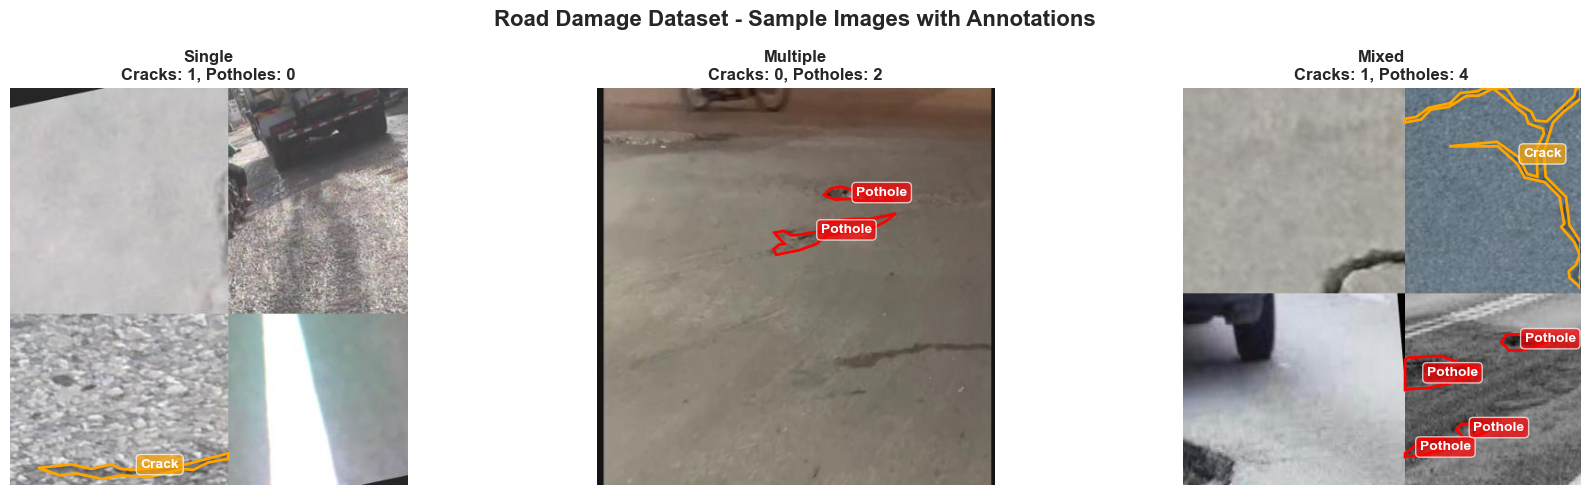

✓ Dataset visualization complete


In [5]:
# Visualize sample images with annotations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Road Damage Dataset - Sample Images with Annotations', fontsize=16, fontweight='bold')

for idx, (key, data) in enumerate(sample_images.items()):
    if data is None:
        continue
    
    img_file, img, annots, (width, height) = data
    ax = axes[idx]
    
    # Display image
    ax.imshow(img)
    
    # Draw polygons
    for ann in annots:
        poly = ann['polygon']
        class_name = ann['class_name']
        color = 'orange' if class_name == 'Crack' else 'red'
        
        # Draw polygon
        polygon = Polygon(poly, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(polygon)
        
        # Add label
        centroid = poly.mean(axis=0)
        ax.text(centroid[0], centroid[1], class_name, 
               bbox=dict(boxstyle='round', facecolor=color, alpha=0.7),
               fontsize=10, fontweight='bold', color='white')
    
    # Labels
    crack_count = sum(1 for a in annots if a['class_id'] == 0)
    pothole_count = sum(1 for a in annots if a['class_id'] == 1)
    
    title = f"{key.capitalize()}\n"
    title += f"Cracks: {crack_count}, Potholes: {pothole_count}"
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Dataset visualization complete")

In [6]:
# Analyze dataset statistics
stats = {
    'train': {'total': 0, 'with_annots': 0, 'cracks': 0, 'potholes': 0, 'sizes': []},
    'valid': {'total': 0, 'with_annots': 0, 'cracks': 0, 'potholes': 0, 'sizes': []},
}

for split in ['train', 'valid']:
    img_dir = os.path.join(DATA_DIR, split, 'images')
    label_dir = os.path.join(DATA_DIR, split, 'labels')
    
    image_files = os.listdir(img_dir)
    print(f"\nAnalyzing {split} set... ({len(image_files)} images)")
    
    for img_file in image_files[:500]:  # Sample first 500 for speed
        img, annots, (w, h) = load_image_with_labels(img_dir, label_dir, img_file)
        if img is None:
            continue
        
        stats[split]['total'] += 1
        stats[split]['sizes'].append((w, h))
        
        if len(annots) > 0:
            stats[split]['with_annots'] += 1
            for ann in annots:
                if ann['class_id'] == 0:
                    stats[split]['cracks'] += 1
                else:
                    stats[split]['potholes'] += 1

# Display statistics
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)

for split, data in stats.items():
    print(f"\n{split.upper()} SET:")
    print(f"  Total images: {data['total']}")
    print(f"  Images with annotations: {data['with_annots']} ({100*data['with_annots']/data['total']:.1f}%)")
    print(f"  Total Cracks: {data['cracks']}")
    print(f"  Total Potholes: {data['potholes']}")
    print(f"  Total objects: {data['cracks'] + data['potholes']}")
    
    if data['sizes']:
        sizes = np.array(data['sizes'])
        print(f"  Image size (W): {sizes[:, 0].mean():.0f} ± {sizes[:, 0].std():.0f} px")
        print(f"  Image size (H): {sizes[:, 1].mean():.0f} ± {sizes[:, 1].std():.0f} px")


Analyzing train set... (4752 images)

Analyzing valid set... (509 images)

DATASET STATISTICS

TRAIN SET:
  Total images: 500
  Images with annotations: 489 (97.8%)
  Total Cracks: 1222
  Total Potholes: 427
  Total objects: 1649
  Image size (W): 432 ± 0 px
  Image size (H): 432 ± 0 px

VALID SET:
  Total images: 500
  Images with annotations: 444 (88.8%)
  Total Cracks: 545
  Total Potholes: 481
  Total objects: 1026
  Image size (W): 432 ± 0 px
  Image size (H): 432 ± 0 px


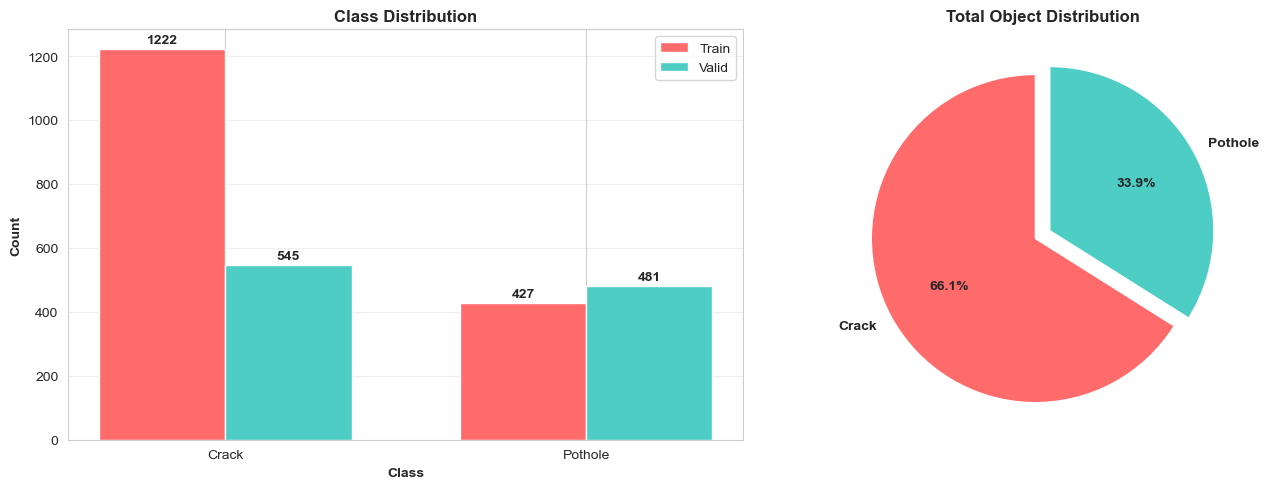

✓ Statistics visualization complete


In [7]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution
classes = ['Crack', 'Pothole']
train_counts = [stats['train']['cracks'], stats['train']['potholes']]
valid_counts = [stats['valid']['cracks'], stats['valid']['potholes']]

x = np.arange(len(classes))
width = 0.35

axes[0].bar(x - width/2, train_counts, width, label='Train', color='#FF6B6B')
axes[0].bar(x + width/2, valid_counts, width, label='Valid', color='#4ECDC4')
axes[0].set_xlabel('Class', fontweight='bold')
axes[0].set_ylabel('Count', fontweight='bold')
axes[0].set_title('Class Distribution', fontweight='bold', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(train_counts):
    axes[0].text(i - width/2, v + 20, str(v), ha='center', fontweight='bold')
for i, v in enumerate(valid_counts):
    axes[0].text(i + width/2, v + 20, str(v), ha='center', fontweight='bold')

# Plot 2: Pie chart of total objects
total_cracks = stats['train']['cracks'] + stats['valid']['cracks']
total_potholes = stats['train']['potholes'] + stats['valid']['potholes']
colors = ['#FF6B6B', '#4ECDC4']
explode = (0.05, 0.05)

axes[1].pie([total_cracks, total_potholes], labels=classes, autopct='%1.1f%%',
           colors=colors, explode=explode, startangle=90, textprops={'fontweight': 'bold'})
axes[1].set_title('Total Object Distribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("✓ Statistics visualization complete")

# Part 3: Image Segmentation (Phân Vùng Hình Ảnh)

In [8]:
def create_segmentation_mask(img_shape, annotations):
    """
    Create binary segmentation masks from polygon annotations
    
    Returns:
    - mask_all: Combined mask of all objects
    - mask_crack: Mask of cracks only
    - mask_pothole: Mask of potholes only
    """
    height, width = img_shape[:2]
    
    mask_all = np.zeros((height, width), dtype=np.uint8)
    mask_crack = np.zeros((height, width), dtype=np.uint8)
    mask_pothole = np.zeros((height, width), dtype=np.uint8)
    
    for ann in annotations:
        poly = ann['polygon'].reshape((-1, 1, 2)).astype(np.int32)
        
        # Draw filled polygon on masks
        cv2.fillPoly(mask_all, [poly], 255)
        
        if ann['class_id'] == 0:  # Crack
            cv2.fillPoly(mask_crack, [poly], 255)
        else:  # Pothole
            cv2.fillPoly(mask_pothole, [poly], 255)
    
    return mask_all, mask_crack, mask_pothole

print("✓ Segmentation mask function defined")

✓ Segmentation mask function defined


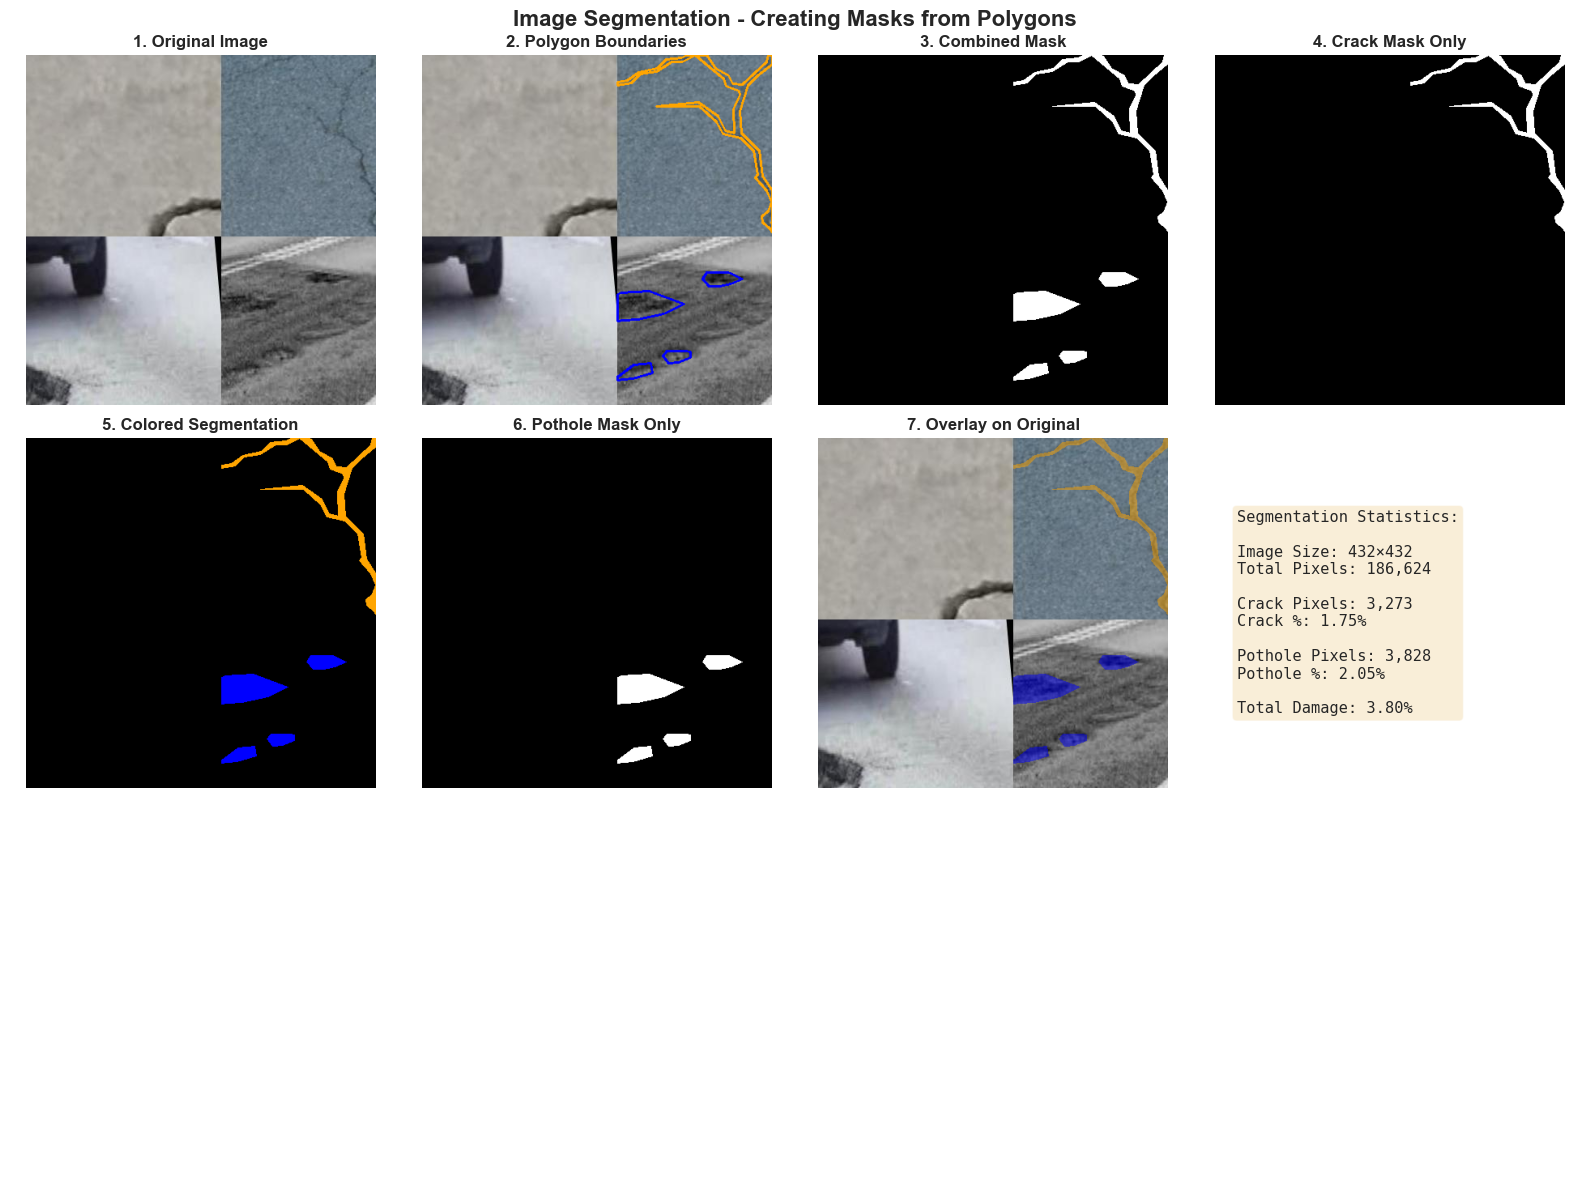

✓ Segmentation visualization complete


In [9]:
# Create and visualize segmentation masks
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Image Segmentation - Creating Masks from Polygons', fontsize=16, fontweight='bold')

# Use mixed sample for better visualization
img_file, img, annots, (width, height) = sample_images['mixed']
mask_all, mask_crack, mask_pothole = create_segmentation_mask(img.shape, annots)

# Row 1: Original image and polygon overlays
axes[0, 0].imshow(img)
axes[0, 0].set_title('1. Original Image', fontweight='bold')
axes[0, 0].axis('off')

# Draw polygons on separate image
img_with_polygons = img.copy()
for ann in annots:
    poly = ann['polygon'].reshape((-1, 1, 2)).astype(np.int32)
    color = (255, 165, 0) if ann['class_id'] == 0 else (0, 0, 255)  # Orange for crack, red for pothole
    cv2.polylines(img_with_polygons, [poly], True, color, 2)

axes[0, 1].imshow(img_with_polygons)
axes[0, 1].set_title('2. Polygon Boundaries', fontweight='bold')
axes[0, 1].axis('off')

# Row 2: Segmentation masks
axes[0, 2].imshow(mask_all, cmap='gray')
axes[0, 2].set_title('3. Combined Mask', fontweight='bold')
axes[0, 2].axis('off')

axes[0, 3].imshow(mask_crack, cmap='gray')
axes[0, 3].set_title('4. Crack Mask Only', fontweight='bold')
axes[0, 3].axis('off')

# Row 3: Colored segmentation
mask_colored = np.zeros((*img.shape[:2], 3), dtype=np.uint8)
mask_colored[mask_crack > 0] = [255, 165, 0]  # Orange for crack
mask_colored[mask_pothole > 0] = [0, 0, 255]  # Red for pothole

axes[1, 0].imshow(mask_colored)
axes[1, 0].set_title('5. Colored Segmentation', fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(mask_pothole, cmap='gray')
axes[1, 1].set_title('6. Pothole Mask Only', fontweight='bold')
axes[1, 1].axis('off')

# Row 4: Overlay on original
overlay = img.copy().astype(float)
overlay[mask_crack > 0] = overlay[mask_crack > 0] * 0.5 + np.array([255, 165, 0]) * 0.5
overlay[mask_pothole > 0] = overlay[mask_pothole > 0] * 0.5 + np.array([0, 0, 255]) * 0.5
overlay = overlay.astype(np.uint8)

axes[1, 2].imshow(overlay)
axes[1, 2].set_title('7. Overlay on Original', fontweight='bold')
axes[1, 2].axis('off')

# Segmentation statistics
ax_text = axes[1, 3]
ax_text.axis('off')

crack_pixels = np.sum(mask_crack > 0)
pothole_pixels = np.sum(mask_pothole > 0)
total_pixels = img.shape[0] * img.shape[1]

stats_text = f"Segmentation Statistics:\n\n"
stats_text += f"Image Size: {img.shape[1]}×{img.shape[0]}\n"
stats_text += f"Total Pixels: {total_pixels:,}\n\n"
stats_text += f"Crack Pixels: {crack_pixels:,}\n"
stats_text += f"Crack %: {100*crack_pixels/total_pixels:.2f}%\n\n"
stats_text += f"Pothole Pixels: {pothole_pixels:,}\n"
stats_text += f"Pothole %: {100*pothole_pixels/total_pixels:.2f}%\n\n"
stats_text += f"Total Damage: {100*(crack_pixels+pothole_pixels)/total_pixels:.2f}%"

ax_text.text(0.1, 0.5, stats_text, fontsize=11, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            family='monospace')

# Remove empty subplots
for i in range(2, 3):
    for j in range(4):
        if i*4 + j >= 8:
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()

print("✓ Segmentation visualization complete")

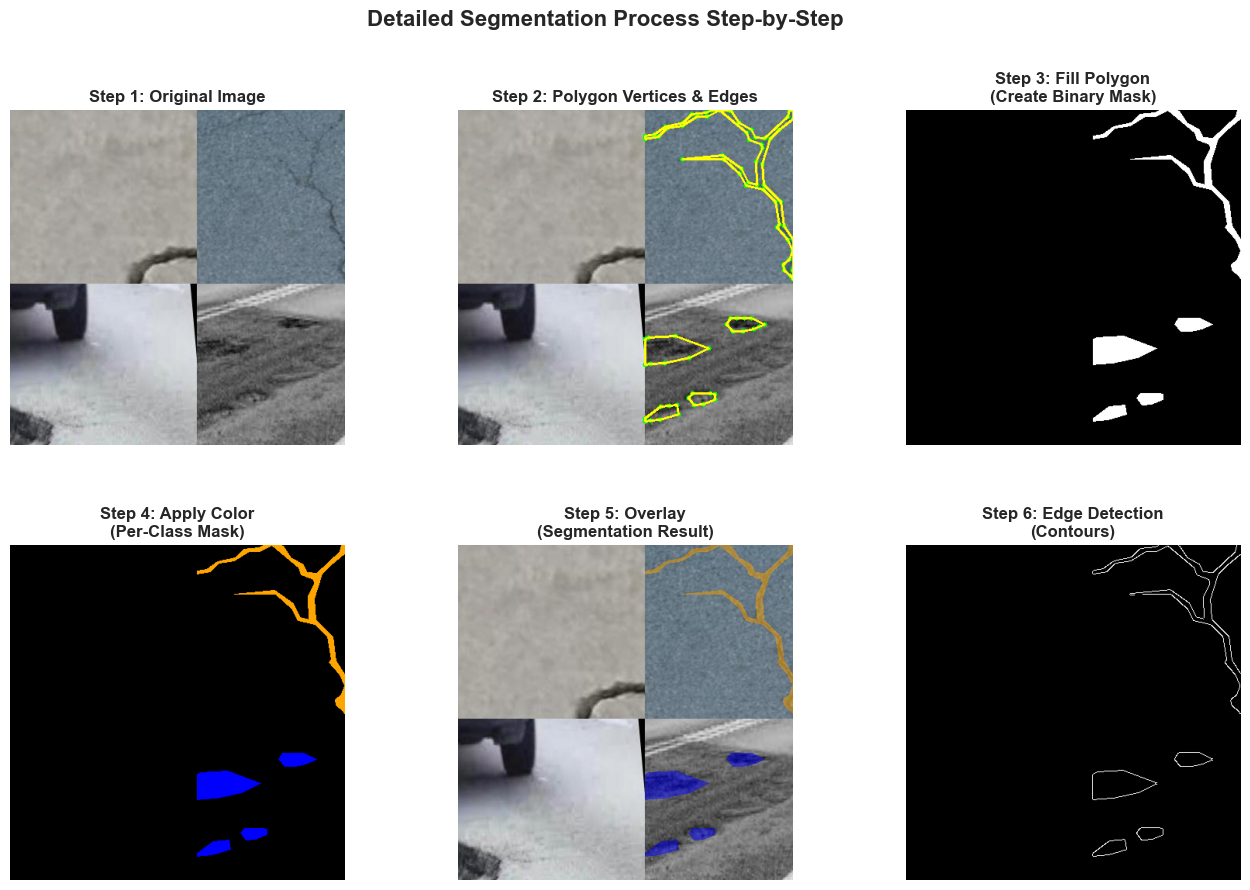

✓ Detailed segmentation process visualization complete


In [10]:
# Detailed segmentation process
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

fig.suptitle('Detailed Segmentation Process Step-by-Step', fontsize=16, fontweight='bold')

# Step 1: Original image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(img)
ax1.set_title('Step 1: Original Image', fontweight='bold')
ax1.axis('off')

# Step 2: Extract polygon coordinates
ax2 = fig.add_subplot(gs[0, 1])
img_points = img.copy()
for ann in annots:
    poly = ann['polygon']
    # Draw points
    for point in poly:
        cv2.circle(img_points, tuple(point.astype(int)), 3, (0, 255, 0), -1)
    # Draw lines between points
    for i in range(len(poly)):
        p1 = tuple(poly[i].astype(int))
        p2 = tuple(poly[(i+1) % len(poly)].astype(int))
        cv2.line(img_points, p1, p2, (255, 255, 0), 2)

ax2.imshow(img_points)
ax2.set_title('Step 2: Polygon Vertices & Edges', fontweight='bold')
ax2.axis('off')

# Step 3: Fill polygon (create mask)
ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(mask_all, cmap='gray')
ax3.set_title('Step 3: Fill Polygon\n(Create Binary Mask)', fontweight='bold')
ax3.axis('off')

# Step 4: Apply colormap
ax4 = fig.add_subplot(gs[1, 0])
ax4.imshow(mask_colored)
ax4.set_title('Step 4: Apply Color\n(Per-Class Mask)', fontweight='bold')
ax4.axis('off')

# Step 5: Overlay on original
ax5 = fig.add_subplot(gs[1, 1])
ax5.imshow(overlay)
ax5.set_title('Step 5: Overlay\n(Segmentation Result)', fontweight='bold')
ax5.axis('off')

# Step 6: Edge detection from mask
ax6 = fig.add_subplot(gs[1, 2])
edges = cv2.Canny(mask_all, 100, 200)
ax6.imshow(edges, cmap='gray')
ax6.set_title('Step 6: Edge Detection\n(Contours)', fontweight='bold')
ax6.axis('off')

plt.show()

print("✓ Detailed segmentation process visualization complete")

# Part 4: Feature Extraction (Trích Xuất Đặc Trưng)

In [11]:
def extract_features(img, mask, polygon):
    """
    Extract features from segmentation mask and image region
    """
    features = {}
    
    # 1. Shape features
    area = np.sum(mask > 0)
    perimeter = cv2.arcLength(polygon.reshape((-1, 1, 2)).astype(np.int32), True)
    
    features['area'] = area
    features['perimeter'] = perimeter
    features['circularity'] = (4 * np.pi * area) / (perimeter ** 2 + 1e-6)
    
    # 2. Bounding box features
    x_coords = polygon[:, 0]
    y_coords = polygon[:, 1]
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()
    
    bbox_width = x_max - x_min
    bbox_height = y_max - y_min
    bbox_area = bbox_width * bbox_height
    
    features['bbox_width'] = bbox_width
    features['bbox_height'] = bbox_height
    features['bbox_area'] = bbox_area
    features['aspect_ratio'] = bbox_width / (bbox_height + 1e-6)
    features['solidity'] = area / (bbox_area + 1e-6)
    
    # 3. Color features (from original image)
    region = img[int(y_min):int(y_max), int(x_min):int(x_max)]
    if region.size > 0:
        # Mean color
        features['mean_r'] = region[:, :, 0].mean()
        features['mean_g'] = region[:, :, 1].mean()
        features['mean_b'] = region[:, :, 2].mean()
        
        # Color variance
        features['std_r'] = region[:, :, 0].std()
        features['std_g'] = region[:, :, 1].std()
        features['std_b'] = region[:, :, 2].std()
    
    # 4. Texture features (from gradient)
    gray = cv2.cvtColor(region.astype(np.uint8), cv2.COLOR_RGB2GRAY) if region.size > 0 else np.zeros((1, 1))
    
    if gray.size > 1:
        # Sobel edges
        sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        
        features['edge_magnitude'] = np.sqrt(sobelx**2 + sobely**2).mean()
        features['edge_variance'] = np.sqrt(sobelx**2 + sobely**2).var()
        
        # Contrast
        features['contrast'] = gray.std()
        features['brightness'] = gray.mean()
    
    return features

print("✓ Feature extraction function defined")

✓ Feature extraction function defined


In [12]:
# Extract features for all objects in the mixed sample
all_features = []
feature_names = None

for idx, ann in enumerate(annots):
    poly = ann['polygon']
    
    # Create mask for this object
    mask_obj = np.zeros(img.shape[:2], dtype=np.uint8)
    poly_reshaped = poly.reshape((-1, 1, 2)).astype(np.int32)
    cv2.fillPoly(mask_obj, [poly_reshaped], 255)
    
    # Extract features
    features = extract_features(img, mask_obj, poly)
    features['object_id'] = idx + 1
    features['class'] = ann['class_name']
    
    all_features.append(features)
    
    if feature_names is None:
        feature_names = list(features.keys())

# Display features as table
import pandas as pd

df_features = pd.DataFrame(all_features)

print("\n" + "="*80)
print("EXTRACTED FEATURES")
print("="*80)
print(df_features.to_string())
print("="*80)


EXTRACTED FEATURES
   area    perimeter  circularity  bbox_width  bbox_height  bbox_area  aspect_ratio  solidity      mean_r      mean_g      mean_b      std_r      std_g      std_b  edge_magnitude  edge_variance   contrast  brightness  object_id    class
0  3273  1091.744614     0.034508         191          218      41638      0.876147  0.078606  103.430880  120.419401  132.957010   8.283863   8.129170   8.391538       33.348007     395.334259   8.188768  116.880013          1    Crack
1  2161   203.995862     0.652562          82           37       3034      2.216216  0.712261   77.354977   77.354977   77.354977  21.874158  21.874158  21.874158       64.057911    1634.177969  21.874158   77.354977          2  Pothole
2   574   106.373424     0.637464          43           21        903      2.047619  0.635659   81.358804   81.358804   81.358804  25.160784  25.160784  25.160784       66.436708    1609.610073  25.160784   81.358804          3  Pothole
3   436    83.491856     0.78597

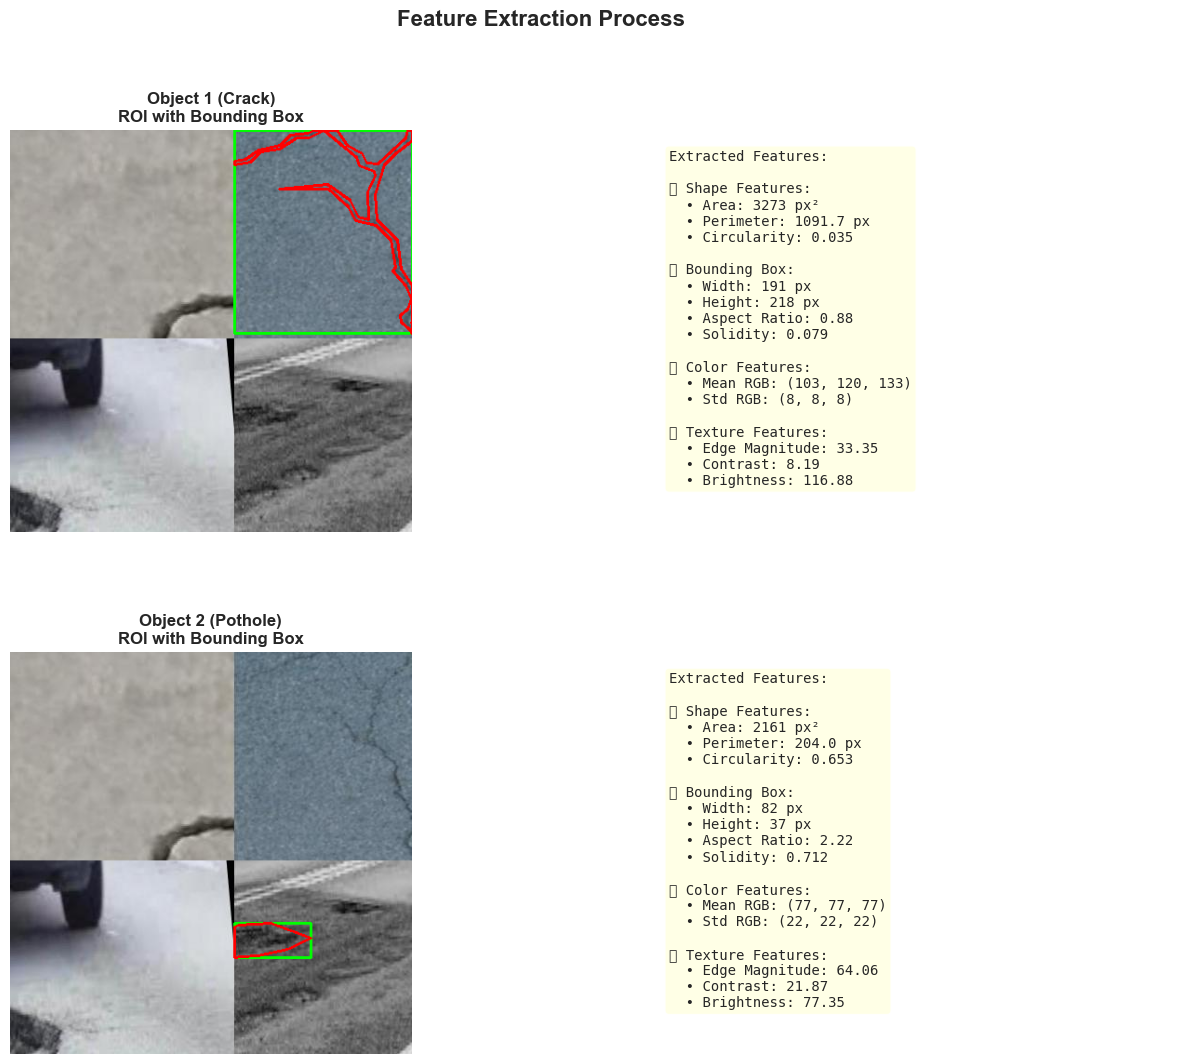

✓ Feature extraction visualization complete


In [13]:
# Visualize feature extraction process
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

fig.suptitle('Feature Extraction Process', fontsize=16, fontweight='bold')

# Iterate through each object
for idx, ann in enumerate(annots[:2]):  # Show first 2 objects
    if idx >= 2:
        break
    
    row = idx
    features = all_features[idx]
    poly = ann['polygon']
    
    # Create masks
    mask_obj = np.zeros(img.shape[:2], dtype=np.uint8)
    poly_reshaped = poly.reshape((-1, 1, 2)).astype(np.int32)
    cv2.fillPoly(mask_obj, [poly_reshaped], 255)
    
    # Get bounding box
    x_min, x_max = int(poly[:, 0].min()), int(poly[:, 0].max())
    y_min, y_max = int(poly[:, 1].min()), int(poly[:, 1].max())
    
    # Left: Original region with bounding box
    ax_left = fig.add_subplot(gs[row, 0])
    img_with_bbox = img.copy()
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
    cv2.polylines(img_with_bbox, [poly_reshaped], True, (255, 0, 0), 2)
    ax_left.imshow(img_with_bbox)
    ax_left.set_title(f"Object {idx+1} ({features['class']})\nROI with Bounding Box", fontweight='bold')
    ax_left.axis('off')
    
    # Right: Feature visualization
    ax_right = fig.add_subplot(gs[row, 1])
    ax_right.axis('off')
    
    # Display extracted features
    feature_text = f"Extracted Features:\n\n"
    feature_text += f"🔷 Shape Features:\n"
    feature_text += f"  • Area: {features['area']} px²\n"
    feature_text += f"  • Perimeter: {features['perimeter']:.1f} px\n"
    feature_text += f"  • Circularity: {features['circularity']:.3f}\n\n"
    
    feature_text += f"📦 Bounding Box:\n"
    feature_text += f"  • Width: {features['bbox_width']} px\n"
    feature_text += f"  • Height: {features['bbox_height']} px\n"
    feature_text += f"  • Aspect Ratio: {features['aspect_ratio']:.2f}\n"
    feature_text += f"  • Solidity: {features['solidity']:.3f}\n\n"
    
    feature_text += f"🎨 Color Features:\n"
    feature_text += f"  • Mean RGB: ({features['mean_r']:.0f}, {features['mean_g']:.0f}, {features['mean_b']:.0f})\n"
    feature_text += f"  • Std RGB: ({features['std_r']:.0f}, {features['std_g']:.0f}, {features['std_b']:.0f})\n\n"
    
    feature_text += f"📊 Texture Features:\n"
    feature_text += f"  • Edge Magnitude: {features['edge_magnitude']:.2f}\n"
    feature_text += f"  • Contrast: {features['contrast']:.2f}\n"
    feature_text += f"  • Brightness: {features['brightness']:.2f}"
    
    ax_right.text(0.05, 0.95, feature_text, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
                 family='monospace', transform=ax_right.transAxes)

plt.show()

print("✓ Feature extraction visualization complete")

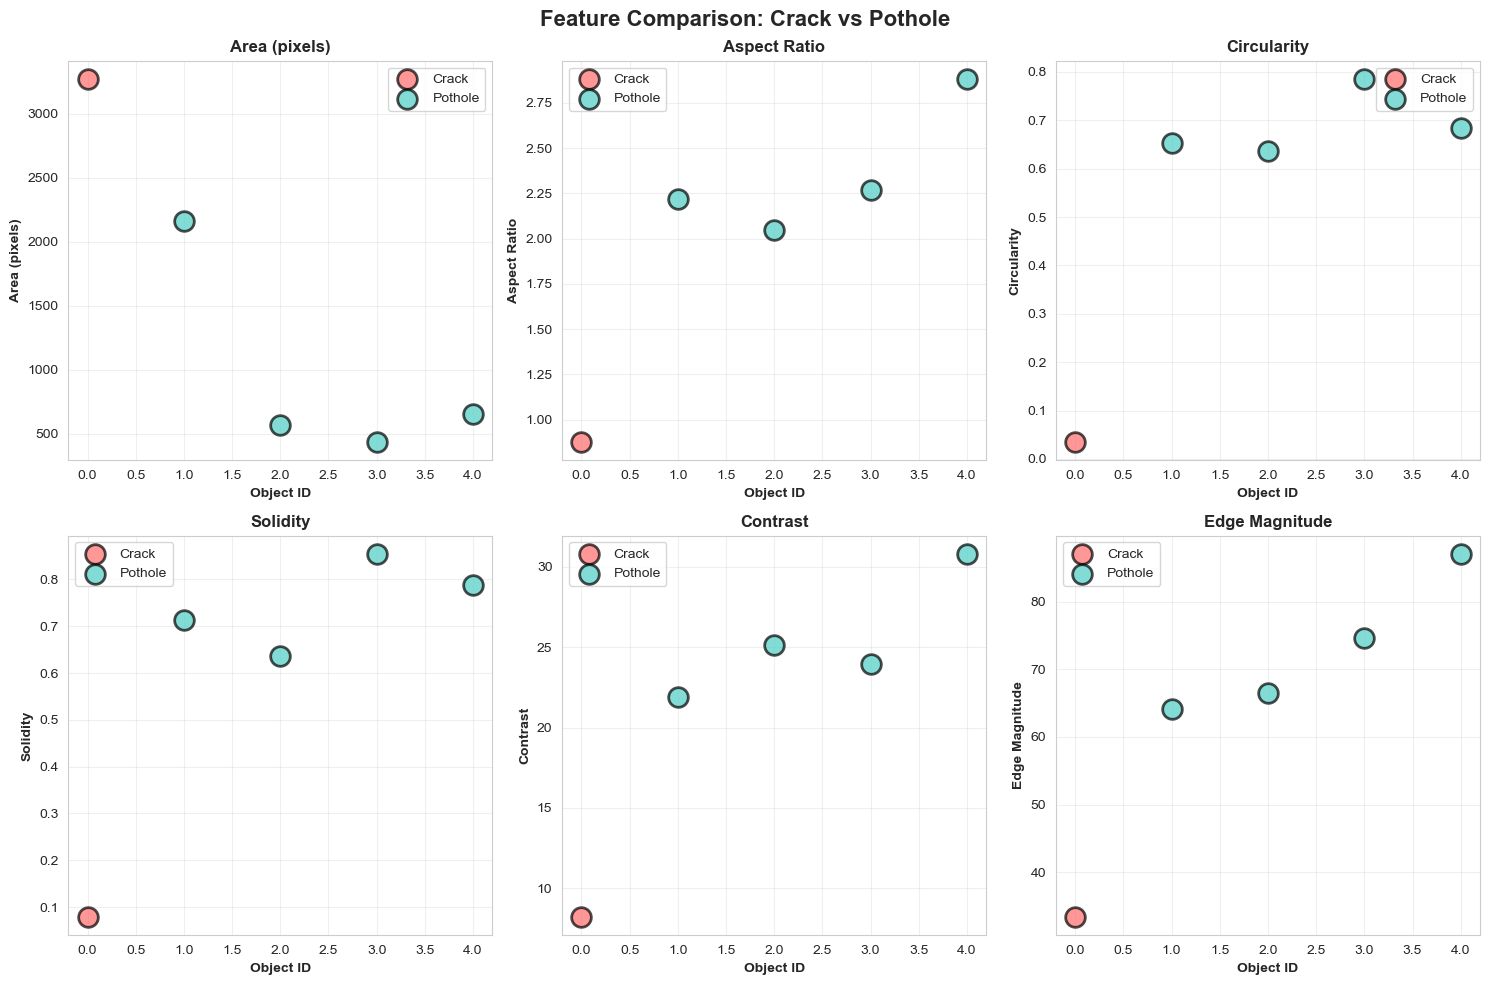

✓ Feature comparison visualization complete


In [14]:
# Visualize feature comparison between Crack and Pothole
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Comparison: Crack vs Pothole', fontsize=16, fontweight='bold')

# Prepare data
df_features = pd.DataFrame(all_features)

# Select key features for visualization
feature_pairs = [
    ('area', 'Area (pixels)'),
    ('aspect_ratio', 'Aspect Ratio'),
    ('circularity', 'Circularity'),
    ('solidity', 'Solidity'),
    ('contrast', 'Contrast'),
    ('edge_magnitude', 'Edge Magnitude')
]

colors = {'Crack': '#FF6B6B', 'Pothole': '#4ECDC4'}

for idx, (feature, label) in enumerate(feature_pairs):
    ax = axes[idx // 3, idx % 3]
    
    # Group by class
    for class_name in ['Crack', 'Pothole']:
        class_data = df_features[df_features['class'] == class_name]
        if len(class_data) > 0:
            ax.scatter(class_data.index, class_data[feature],
                      color=colors[class_name], s=200, alpha=0.7,
                      label=class_name, edgecolors='black', linewidth=2)
    
    ax.set_xlabel('Object ID', fontweight='bold')
    ax.set_ylabel(label, fontweight='bold')
    ax.set_title(label, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("✓ Feature comparison visualization complete")

# Part 5: Feature Statistics & Visualization

In [15]:
# Create comprehensive feature statistics
print("\n" + "="*80)
print("FEATURE STATISTICS SUMMARY")
print("="*80)

feature_columns = ['area', 'perimeter', 'circularity', 'aspect_ratio', 
                   'solidity', 'contrast', 'brightness', 'edge_magnitude']

for feature in feature_columns:
    if feature in df_features.columns:
        print(f"\n{feature.upper()}:")
        print(f"  Mean: {df_features[feature].mean():.2f}")
        print(f"  Std:  {df_features[feature].std():.2f}")
        print(f"  Min:  {df_features[feature].min():.2f}")
        print(f"  Max:  {df_features[feature].max():.2f}")


FEATURE STATISTICS SUMMARY

AREA:
  Mean: 1420.20
  Std:  1249.88
  Min:  436.00
  Max:  3273.00

PERIMETER:
  Mean: 319.08
  Std:  434.39
  Min:  83.49
  Max:  1091.74

CIRCULARITY:
  Mean: 0.56
  Std:  0.30
  Min:  0.03
  Max:  0.79

ASPECT_RATIO:
  Mean: 2.06
  Std:  0.73
  Min:  0.88
  Max:  2.88

SOLIDITY:
  Mean: 0.61
  Std:  0.31
  Min:  0.08
  Max:  0.85

CONTRAST:
  Mean: 22.00
  Std:  8.40
  Min:  8.19
  Max:  30.83

BRIGHTNESS:
  Mean: 88.23
  Std:  17.53
  Min:  73.21
  Max:  116.88

EDGE_MAGNITUDE:
  Mean: 65.10
  Std:  19.90
  Min:  33.35
  Max:  87.08


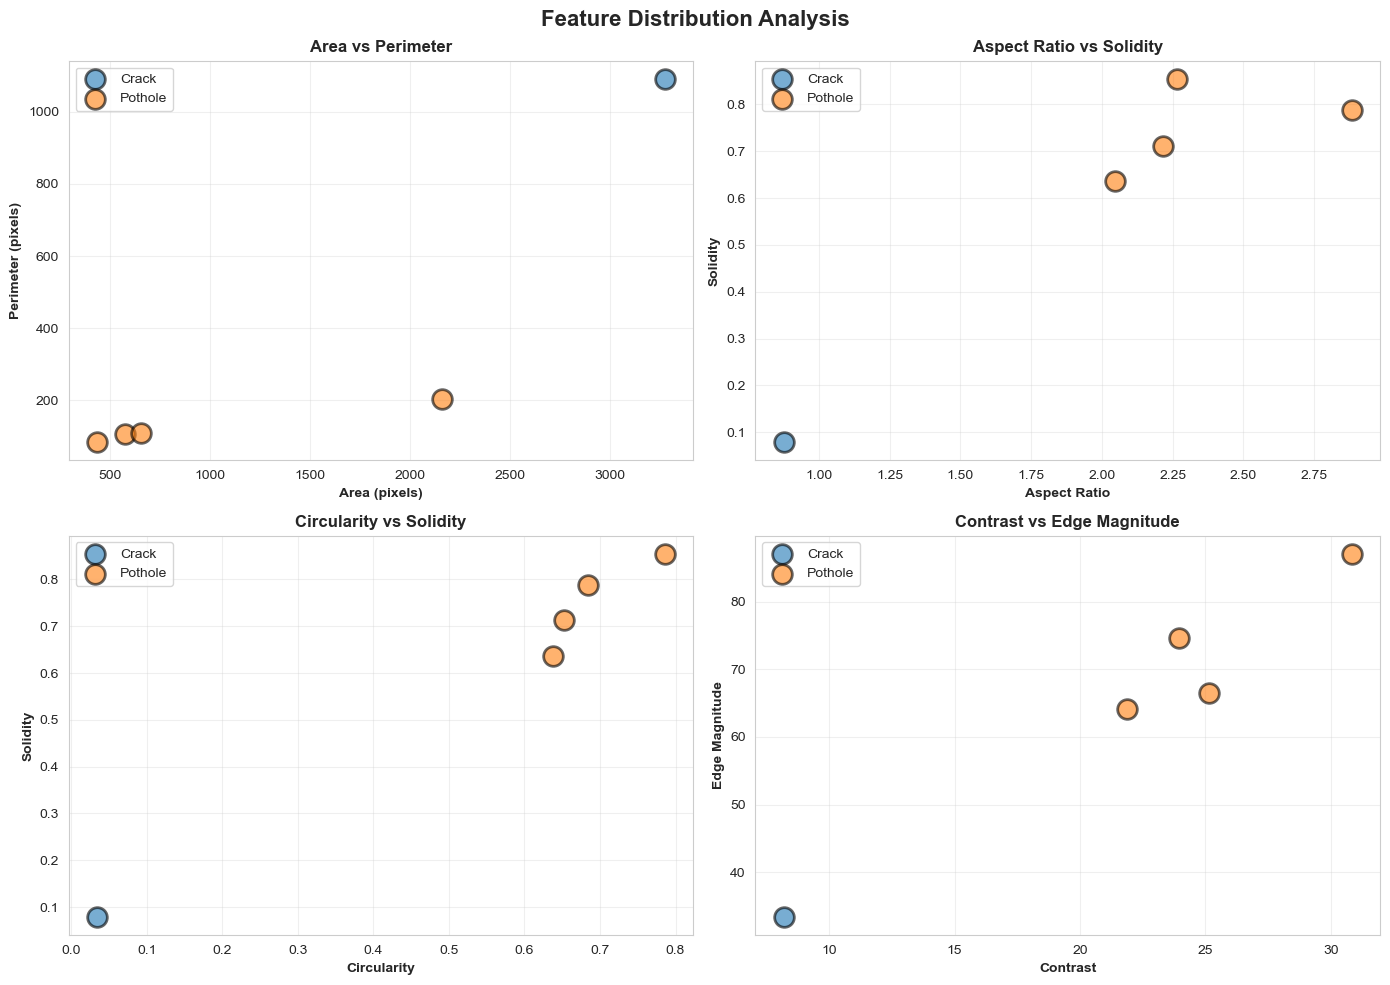

✓ Feature distribution visualization complete


In [16]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution Analysis', fontsize=16, fontweight='bold')

# Plot 1: Area vs Perimeter
ax = axes[0, 0]
for class_name in ['Crack', 'Pothole']:
    class_data = df_features[df_features['class'] == class_name]
    ax.scatter(class_data['area'], class_data['perimeter'],
              s=200, alpha=0.6, label=class_name, edgecolors='black', linewidth=2)
ax.set_xlabel('Area (pixels)', fontweight='bold')
ax.set_ylabel('Perimeter (pixels)', fontweight='bold')
ax.set_title('Area vs Perimeter', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Aspect Ratio vs Solidity
ax = axes[0, 1]
for class_name in ['Crack', 'Pothole']:
    class_data = df_features[df_features['class'] == class_name]
    ax.scatter(class_data['aspect_ratio'], class_data['solidity'],
              s=200, alpha=0.6, label=class_name, edgecolors='black', linewidth=2)
ax.set_xlabel('Aspect Ratio', fontweight='bold')
ax.set_ylabel('Solidity', fontweight='bold')
ax.set_title('Aspect Ratio vs Solidity', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Circularity vs Solidity
ax = axes[1, 0]
for class_name in ['Crack', 'Pothole']:
    class_data = df_features[df_features['class'] == class_name]
    ax.scatter(class_data['circularity'], class_data['solidity'],
              s=200, alpha=0.6, label=class_name, edgecolors='black', linewidth=2)
ax.set_xlabel('Circularity', fontweight='bold')
ax.set_ylabel('Solidity', fontweight='bold')
ax.set_title('Circularity vs Solidity', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Contrast vs Edge Magnitude
ax = axes[1, 1]
for class_name in ['Crack', 'Pothole']:
    class_data = df_features[df_features['class'] == class_name]
    ax.scatter(class_data['contrast'], class_data['edge_magnitude'],
              s=200, alpha=0.6, label=class_name, edgecolors='black', linewidth=2)
ax.set_xlabel('Contrast', fontweight='bold')
ax.set_ylabel('Edge Magnitude', fontweight='bold')
ax.set_title('Contrast vs Edge Magnitude', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Feature distribution visualization complete")

# Summary & Conclusions

In [17]:
print("\n" + "="*80)
print("📊 VISUALIZATION SUMMARY")
print("="*80)

print("""
1. DATASET VISUALIZATION:
   ✓ Loaded and displayed sample images from training set
   ✓ Visualized polygon annotations on images
   ✓ Analyzed class distribution (Crack vs Pothole)
   ✓ Computed dataset statistics

2. IMAGE SEGMENTATION:
   ✓ Converted YOLO polygon format to binary masks
   ✓ Created per-class segmentation masks
   ✓ Generated colored segmentation overlays
   ✓ Visualized step-by-step segmentation process
   ✓ Computed damage coverage statistics

3. FEATURE EXTRACTION:
   ✓ Extracted shape features (area, perimeter, circularity)
   ✓ Computed bounding box features (aspect ratio, solidity)
   ✓ Calculated color features (RGB mean, variance)
   ✓ Analyzed texture features (edge magnitude, contrast)
   ✓ Compared features between Crack and Pothole

4. FEATURE ANALYSIS:
   ✓ Visualized feature distributions
   ✓ Created scatter plots for feature relationships
   ✓ Computed feature statistics (mean, std, min, max)
""")

print("="*80)
print("KEY INSIGHTS:")
print("="*80)

# Compare crack vs pothole features
crack_features = df_features[df_features['class'] == 'Crack']
pothole_features = df_features[df_features['class'] == 'Pothole']

if len(crack_features) > 0 and len(pothole_features) > 0:
    print(f"\n1. SHAPE CHARACTERISTICS:")
    print(f"   Cracks:")
    print(f"     - Average Aspect Ratio: {crack_features['aspect_ratio'].mean():.2f}")
    print(f"     - Average Circularity: {crack_features['circularity'].mean():.3f}")
    print(f"   Potholes:")
    print(f"     - Average Aspect Ratio: {pothole_features['aspect_ratio'].mean():.2f}")
    print(f"     - Average Circularity: {pothole_features['circularity'].mean():.3f}")
    
    print(f"\n2. SIZE CHARACTERISTICS:")
    print(f"   Cracks:")
    print(f"     - Average Area: {crack_features['area'].mean():.0f} pixels")
    print(f"     - Average Perimeter: {crack_features['perimeter'].mean():.0f} pixels")
    print(f"   Potholes:")
    print(f"     - Average Area: {pothole_features['area'].mean():.0f} pixels")
    print(f"     - Average Perimeter: {pothole_features['perimeter'].mean():.0f} pixels")
    
    print(f"\n3. TEXTURE CHARACTERISTICS:")
    print(f"   Cracks:")
    print(f"     - Average Edge Magnitude: {crack_features['edge_magnitude'].mean():.2f}")
    print(f"     - Average Contrast: {crack_features['contrast'].mean():.2f}")
    print(f"   Potholes:")
    print(f"     - Average Edge Magnitude: {pothole_features['edge_magnitude'].mean():.2f}")
    print(f"     - Average Contrast: {pothole_features['contrast'].mean():.2f}")

print("\n" + "="*80)
print("✓ All visualizations complete!")
print("="*80)


📊 VISUALIZATION SUMMARY

1. DATASET VISUALIZATION:
   ✓ Loaded and displayed sample images from training set
   ✓ Visualized polygon annotations on images
   ✓ Analyzed class distribution (Crack vs Pothole)
   ✓ Computed dataset statistics

2. IMAGE SEGMENTATION:
   ✓ Converted YOLO polygon format to binary masks
   ✓ Created per-class segmentation masks
   ✓ Generated colored segmentation overlays
   ✓ Visualized step-by-step segmentation process
   ✓ Computed damage coverage statistics

3. FEATURE EXTRACTION:
   ✓ Extracted shape features (area, perimeter, circularity)
   ✓ Computed bounding box features (aspect ratio, solidity)
   ✓ Calculated color features (RGB mean, variance)
   ✓ Analyzed texture features (edge magnitude, contrast)
   ✓ Compared features between Crack and Pothole

4. FEATURE ANALYSIS:
   ✓ Visualized feature distributions
   ✓ Created scatter plots for feature relationships
   ✓ Computed feature statistics (mean, std, min, max)

KEY INSIGHTS:

1. SHAPE CHARACTE